In [3]:
# Introduction to Data Assimilation with Lorenz-63

#This notebook demonstrates basic data assimilation concepts using the Lorenz-63 chaotic system.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [7]:
def lorenz63(t, state, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]

In [8]:
t = np.linspace(0, 20, 2000)

x0 = [1.0, 1.0, 1.0]

sol = solve_ivp(
    lorenz63,
    [t[0], t[-1]],
    x0,
    t_eval=t
)

truth = sol.y.T

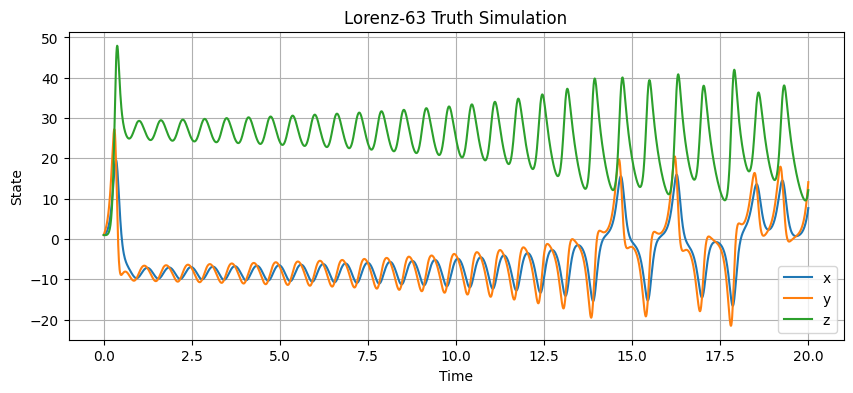

In [9]:
plt.figure(figsize=(10,4))

plt.plot(t, truth[:,0], label='x')
plt.plot(t, truth[:,1], label='y')
plt.plot(t, truth[:,2], label='z')

plt.xlabel('Time')
plt.ylabel('State')

plt.title('Lorenz-63 Truth Simulation')

plt.legend()
plt.grid()

plt.show()

In [10]:
obs_interval = 20

obs_indices = np.arange(0, len(t), obs_interval)

obs_noise_std = 2.0

observations = (
    truth[obs_indices, 0]
    + np.random.normal(0, obs_noise_std, len(obs_indices))
)

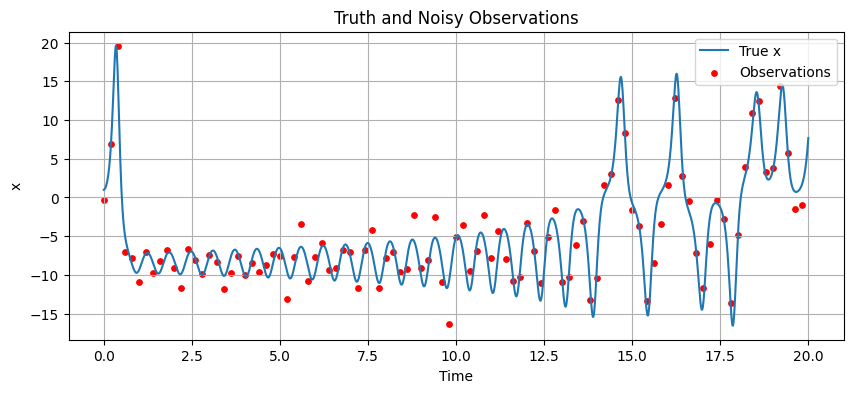

In [11]:
plt.figure(figsize=(10,4))

plt.plot(t, truth[:,0], label='True x')

plt.scatter(
    t[obs_indices],
    observations,
    color='red',
    s=15,
    label='Observations'
)

plt.xlabel('Time')
plt.ylabel('x')

plt.title('Truth and Noisy Observations')

plt.legend()
plt.grid()

plt.show()